# Which water mains to replace: Gaussian processes and decision theory

A Gaussian process returns a full predictive distribution, not a point estimate.
Decision theory (Rasmussen and Williams, chapter 2) turns that distribution into
the action that minimizes expected loss.

We predict water main break rates across the City of Kitchener from its open
break records, then decide which pipes to replace, in dollars.

In [1]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.collections import LineCollection
import pytensor.tensor as pt
import pymc as pm
import ptgp as pg
from ptgp.likelihoods.base import Likelihood

# City of Kitchener open data (ArcGIS feature services)
BREAKS_URL = "https://services1.arcgis.com/qAo1OsXi67t7XgmS/arcgis/rest/services/Water_Main_Breaks/FeatureServer/0"
MAINS_URL = "https://services1.arcgis.com/qAo1OsXi67t7XgmS/arcgis/rest/services/Water_Mains/FeatureServer/0"

def _fetch(url, page=2000):
    feats, off = [], 0
    while True:
        r = requests.get(url + "/query", params=dict(where="1=1", outFields="*", f="geojson",
                         outSR=4326, resultOffset=off, resultRecordCount=page), timeout=120)
        r.raise_for_status()
        b = r.json().get("features", []); feats += b
        if len(b) < page:
            break
        off += page
    return feats

bf, mf = _fetch(BREAKS_URL), _fetch(MAINS_URL)
breaks = pd.DataFrame([f["properties"] for f in bf])
breaks["lon"] = [f["geometry"]["coordinates"][0] if f["geometry"] else np.nan for f in bf]
breaks["lat"] = [f["geometry"]["coordinates"][1] if f["geometry"] else np.nan for f in bf]
mains = pd.DataFrame([f["properties"] for f in mf])
mains_geoms = [f["geometry"] for f in mf]
mains["install_year"] = pd.to_datetime(mains["INSTALLATION_DATE"], unit="ms", errors="coerce").dt.year

def _centroid(g):
    if not g:
        return (np.nan, np.nan)
    cs = g["coordinates"] if g["type"] == "LineString" else [p for pa in g["coordinates"] for p in pa]
    a = np.asarray(cs, float); return a[:, 0].mean(), a[:, 1].mean()
cent = np.array([_centroid(g) for g in mains_geoms]); mains["lon"], mains["lat"] = cent[:, 0], cent[:, 1]

AS_OF, START = 2026.0, 1985.0
mb = breaks[breaks["BREAK_TYPE"].eq("MAIN")]
bc = mb.loc[mb["ASSETID"].isin(set(mains["WATMAINID"])), "ASSETID"].value_counts()
mains["n_breaks"] = mains["WATMAINID"].map(bc).fillna(0).astype(int)

m = mains[(mains["STATUS"] == "ACTIVE") & mains["install_year"].between(1850, 2026)].copy()
m["age"] = AS_OF - m["install_year"]
m["length_km"] = m["Shape__Length"] / 1000.0
m["exposure"] = m["length_km"] * (AS_OF - np.maximum(m["install_year"], START))  # pipe-km-years at risk
m = m[(m["exposure"] > 0) & m["lat"].notna() & m["PIPE_SIZE"].between(25, 1200)]

# Features: standardized continuous + one-hot material and pressure zone
cont = pd.DataFrame({"age": m["age"].to_numpy(float), "log_size": np.log(m["PIPE_SIZE"].to_numpy(float)),
                     "lon": m["lon"].to_numpy(float), "lat": m["lat"].to_numpy(float)})
cont_mean, cont_std = cont.mean(), cont.std()
mat = m["MATERIAL"].to_numpy()
onehot = np.column_stack([(mat == k).astype(float) for k in ("CI", "DI", "PVC")])
TOP_PZ = ["KIT 4", "KIT 5", "KIT 2W", "KIT 6", "KIT 2E", "BRIDGEPORT"]
pzoh = np.column_stack([(m["PRESSURE_ZONE"].to_numpy() == z).astype(float) for z in TOP_PZ])
Xfeat = np.column_stack([((cont - cont_mean) / cont_std).to_numpy(), onehot, pzoh]).astype(np.float64)
log_expo = np.log(m["exposure"].to_numpy(float))
y = m["n_breaks"].to_numpy(float)
length_km = m["length_km"].to_numpy(float)

segs = []
for g in mains_geoms:
    if g:
        segs += ([g["coordinates"]] if g["type"] == "LineString" else g["coordinates"])
colors = {"CI": "tab:red", "DI": "tab:orange", "PVC": "tab:green"}
print(f"{len(m)} active mains, {int(y.sum())} main breaks; feature dims {Xfeat.shape[1]}")


16163 active mains, 2415 main breaks; feature dims 13


## The data

The city publishes every water main and every recorded break since 1985. Breaks
concentrate in the older cast-iron core; the newer plastic subdivisions on the
edges stay quiet.

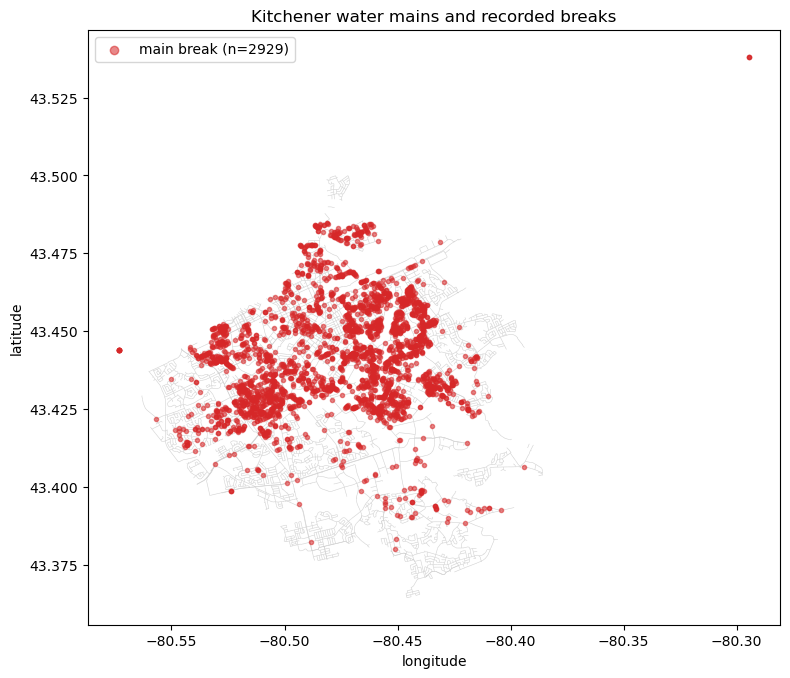

In [2]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(LineCollection(segs, colors="0.82", linewidths=0.4, zorder=1))
ax.scatter(mb["lon"], mb["lat"], s=9, c="tab:red", alpha=0.55, zorder=2, label=f"main break (n={len(mb)})")
ax.set_aspect(1.0 / np.cos(np.deg2rad(43.45))); ax.autoscale()
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title("Kitchener water mains and recorded breaks")
ax.legend(loc="upper left", markerscale=2)
plt.tight_layout(); plt.show()


## A break-rate model

Each main's break count is Poisson, driven by a latent log break-rate that is a
GP over pipe age, size, material, pressure zone, and location. Pipe-km-years of
service enter as a fixed exposure offset. Breaks recur, so this is a rate model,
not a one-shot survival model.

The exposure offset needs a small custom likelihood; everything else is standard
ptgp.

In [3]:
class PoissonExposure(Likelihood):
    """Poisson counts with a fixed log-exposure offset: y ~ Poisson(exposure * exp(f))."""

    def __init__(self, log_exposure, n_points=20):
        self.log_exposure = pt.as_tensor_variable(log_exposure)
        self.invlink, self.n_points = pt.exp, n_points

    def _log_prob(self, f, y):
        loglam = f + self.log_exposure
        return y * loglam - pt.exp(loglam) - pt.gammaln(y + 1.0)

    def variational_expectation(self, y, mu, var):  # closed form for the log link
        e = self.log_exposure
        return y * (mu + e) - pt.exp(e) * pt.exp(mu + var / 2.0) - pt.gammaln(y + 1.0)


M, D = 128, Xfeat.shape[1]
Z0 = Xfeat[np.random.default_rng(0).choice(len(m), M, replace=False)]
vp = pg.gp.init_variational_params(M)

with pm.Model() as model:
    ls = pm.InverseGamma("ls", alpha=3.0, beta=3.0, shape=D)
    eta = pm.HalfNormal("eta", sigma=1.0)
    svgp = pg.gp.SVGP(
        kernel=eta**2 * pg.kernels.Matern52(input_dim=D, ls=ls),
        likelihood=PoissonExposure(log_expo),
        inducing_variable=pg.inducing.Points(pt.as_tensor_variable(Z0)),
        variational_params=vp,
    )

X_var, y_var = pt.matrix("X"), pt.vector("y")
step, shared, extras = pg.optim.compile_training_step(
    lambda gp, X, y: pg.objectives.elbo(gp, X, y, n_data=len(m)).elbo,
    svgp, X_var, y_var, model=model,
    extra_vars=vp.extra_vars, extra_init=vp.extra_init, learning_rate=1e-2)
losses = [float(step(Xfeat, y)) for _ in range(350)]
print(f"trained; loss {losses[0]:.0f} -> {losses[-1]:.0f}")


trained; loss 32372 -> 5127


The fitted rate rises with age and is far higher for cast iron. Each curve
follows its material over the observed age range; dots are the empirical rate.

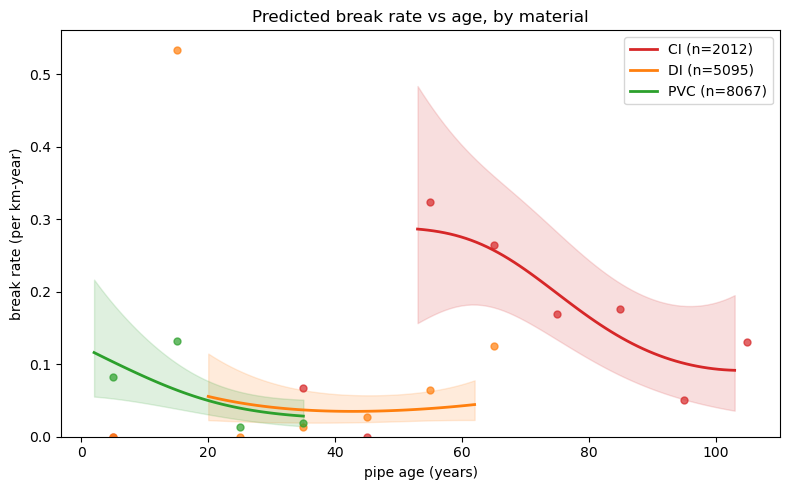

In [4]:
X_new = pt.matrix("X_new")
predict_latent = pg.optim.compile_predict(svgp, X_new, model, shared,
                                          extra_vars=vp.extra_vars, shared_extras=extras, incl_lik=False)

def rate_at(Xq):
    fm, fv = predict_latent(np.asarray(Xq, float))
    return np.exp(fm + 0.5 * fv), fm, fv

rate_all, fm_all, fv_all = rate_at(Xfeat)
age_real = m["age"].to_numpy(float)

fig, ax = plt.subplots(figsize=(8, 5))
for name, c in {"CI": 4, "DI": 5, "PVC": 6}.items():
    idx = Xfeat[:, c] == 1
    base = Xfeat[idx].mean(axis=0)
    lo, hi = np.percentile(age_real[idx], [2, 98])
    ages = np.linspace(lo, hi, 60)
    Xq = np.tile(base, (len(ages), 1)); Xq[:, 0] = (ages - cont_mean["age"]) / cont_std["age"]
    r, fmm, fvv = rate_at(Xq); sd = np.sqrt(fvv)
    ax.plot(ages, r, color=colors[name], lw=2, label=f"{name} (n={int(idx.sum())})")
    ax.fill_between(ages, np.exp(fmm - 2 * sd), np.exp(fmm + 2 * sd), color=colors[name], alpha=0.15)
    sub = m[idx].assign(ab=(age_real[idx] // 10 * 10))
    e = sub.groupby("ab").apply(lambda d: d["n_breaks"].sum() / d["exposure"].sum(), include_groups=False)
    ax.plot(e[e.index <= hi].index + 5, e[e.index <= hi].values, "o", color=colors[name], ms=5, alpha=0.7)
ax.set_xlabel("pipe age (years)"); ax.set_ylabel("break rate (per km-year)")
ax.set_title("Predicted break rate vs age, by material"); ax.legend(); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()


## Risk across the network

Predicting every main, including the ones that have never broken, gives a risk
map: bright where the model expects frequent breaks, dark where it does not.

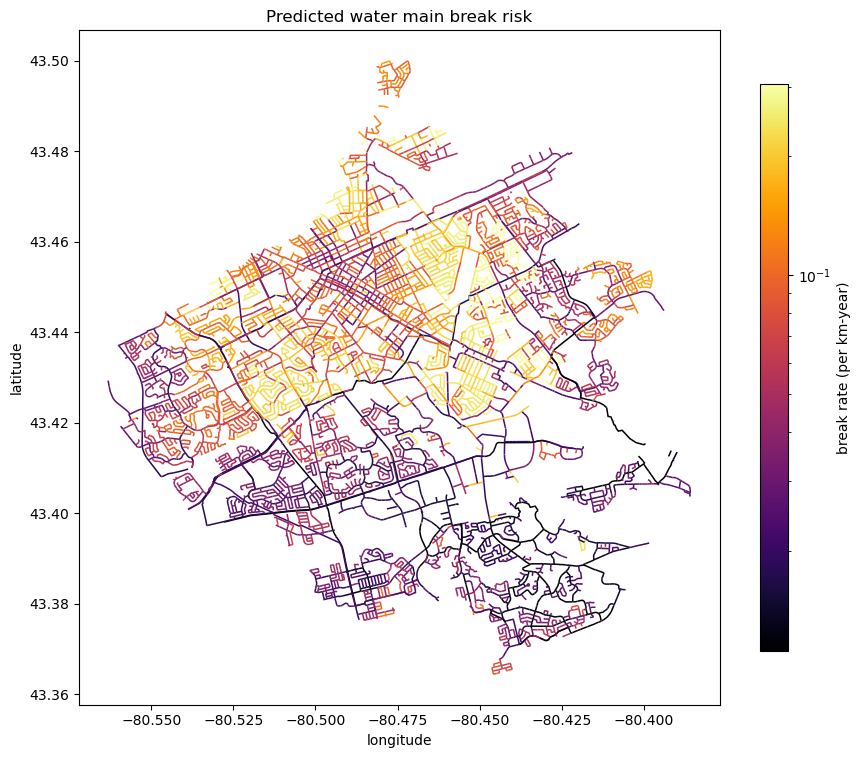

In [5]:
geoms_m = [mains_geoms[i] for i in m.index]
sg, sr = [], []
for g, r in zip(geoms_m, rate_all):
    if not g:
        continue
    for p in ([g["coordinates"]] if g["type"] == "LineString" else g["coordinates"]):
        sg.append(p); sr.append(r)
sr = np.asarray(sr)

fig, ax = plt.subplots(figsize=(9, 8.5))
norm = mpl.colors.LogNorm(vmin=max(np.quantile(sr, 0.02), 1e-3), vmax=np.quantile(sr, 0.99))
lc = LineCollection(sg, array=sr, cmap="inferno", norm=norm, linewidths=1.1)
ax.add_collection(lc)
ax.set_aspect(1.0 / np.cos(np.deg2rad(43.45))); ax.autoscale()
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title("Predicted water main break risk")
plt.colorbar(lc, ax=ax, label="break rate (per km-year)", shrink=0.7)
plt.tight_layout(); plt.show()


## From risk to decisions

Decision theory picks the action that minimizes expected loss over the predictive
distribution (R&W eq. 2.32 to 2.33). The action here is replace now or defer:
replace when the expected cost of future breaks over a planning horizon exceeds
the replacement cost. The expected cost integrates the whole GP predictive, not
just the mean latent, so uncertain pipes get flagged that a point estimate misses.

In [6]:
H, C_break = 30.0, 25000.0                                   # horizon (years), cost per break ($)
replace_cost = (150.0 + 0.7 * m["PIPE_SIZE"].to_numpy(float)) * length_km * 1000.0   # $/m x length

rate_exp = np.exp(fm_all + 0.5 * fv_all)                     # E[rate]: integrates the GP predictive
rate_plug = np.exp(fm_all)                                   # plug-in of the mean latent

def flagged(rate):
    return rate * length_km * H * C_break > replace_cost      # replace if expected break cost > replace cost

repl_dt, repl_naive = flagged(rate_exp), flagged(rate_plug)
print(f"replace flagged: decision-theoretic {int(repl_dt.sum())}, plug-in {int(repl_naive.sum())}, "
      f"flagged by uncertainty only {int((repl_dt & ~repl_naive).sum())}")


replace flagged: decision-theoretic 58, plug-in 23, flagged by uncertainty only 35


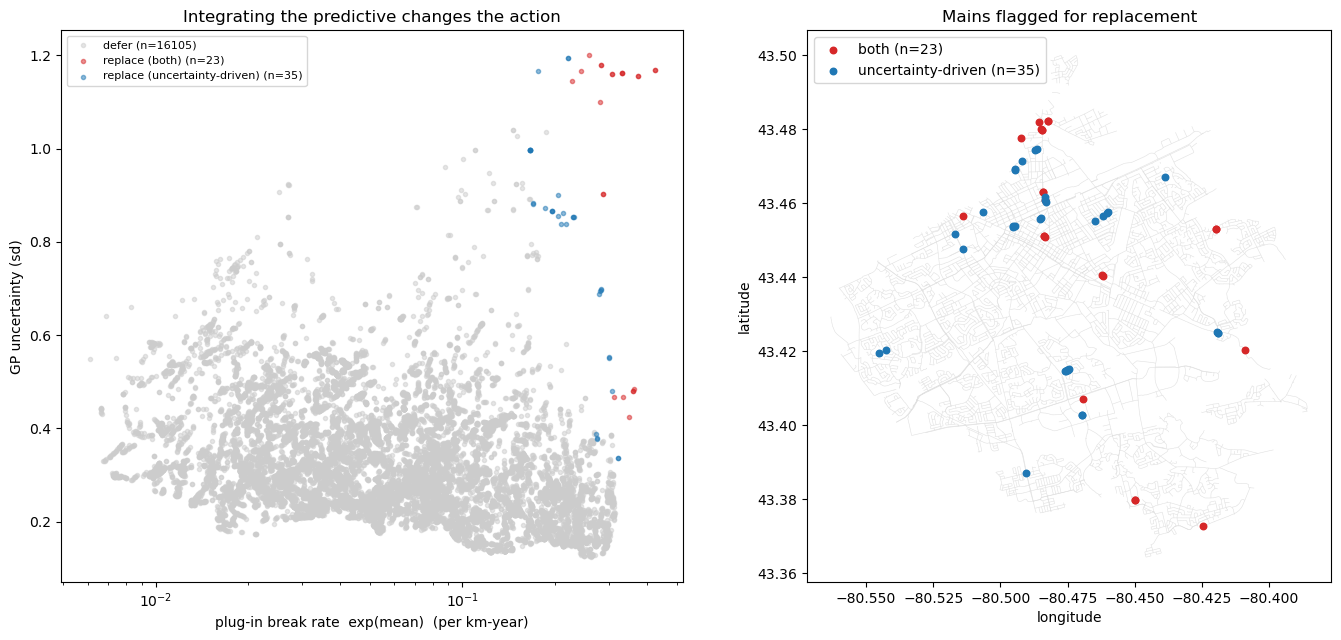

In [7]:
cat = np.where(repl_naive, 1, np.where(repl_dt, 2, 0))
sd = np.sqrt(fv_all)
fig, ax = plt.subplots(1, 2, figsize=(14, 6.5))
for c, (col, lab) in {0: ("0.8", "defer"), 1: ("tab:red", "replace (both)"),
                      2: ("tab:blue", "replace (uncertainty-driven)")}.items():
    sel = cat == c
    ax[0].scatter(np.exp(fm_all[sel]), sd[sel], s=9, c=col, alpha=0.5, label=f"{lab} (n={int(sel.sum())})")
ax[0].set_xscale("log"); ax[0].set_xlabel("plug-in break rate  exp(mean)  (per km-year)")
ax[0].set_ylabel("GP uncertainty (sd)")
ax[0].set_title("Integrating the predictive changes the action"); ax[0].legend(loc="upper left", fontsize=8)

ax[1].add_collection(LineCollection(segs, colors="0.88", linewidths=0.4, zorder=1))
fl = m.assign(cat=cat)
for c, (col, lab) in {1: ("tab:red", "both"), 2: ("tab:blue", "uncertainty-driven")}.items():
    s = fl[fl["cat"] == c]
    ax[1].scatter(s["lon"], s["lat"], s=22, c=col, label=f"{lab} (n={len(s)})", zorder=3)
ax[1].set_aspect(1.0 / np.cos(np.deg2rad(43.45))); ax[1].autoscale()
ax[1].set_xlabel("longitude"); ax[1].set_ylabel("latitude")
ax[1].set_title("Mains flagged for replacement"); ax[1].legend(loc="upper left")
plt.tight_layout(); plt.show()


## Asymmetric loss

That decision was risk-neutral, so only the mean mattered. Real losses are
asymmetric: an unplanned break beyond the crew's provisioned budget costs a surge
premium, while reserving capacity that goes unused is cheaper. Under an asymmetric
loss the optimal action is a quantile of the predictive, not its mean, and the gap
grows with uncertainty. We propagate the GP predictive to the distribution of
annual network breaks and choose the emergency-provisioning budget.

In [8]:
rng = np.random.default_rng(7)
sd_all = np.sqrt(fv_all)
S = 2000
totals = np.array([rng.poisson(np.exp(fm_all + sd_all * rng.standard_normal(len(m))) * length_km).sum()
                   for _ in range(S)])                      # predictive of annual network breaks

C_surge, C_idle = 40000.0, 8000.0                            # surge premium vs idle-capacity cost
q = C_surge / (C_surge + C_idle)                             # newsvendor critical fractile
Bstar = int(np.ceil(np.quantile(totals, q)))
print(f"annual breaks: mean {totals.mean():.0f}; optimal budget B* = quantile({q:.2f}) = {Bstar}")


annual breaks: mean 79; optimal budget B* = quantile(0.83) = 88


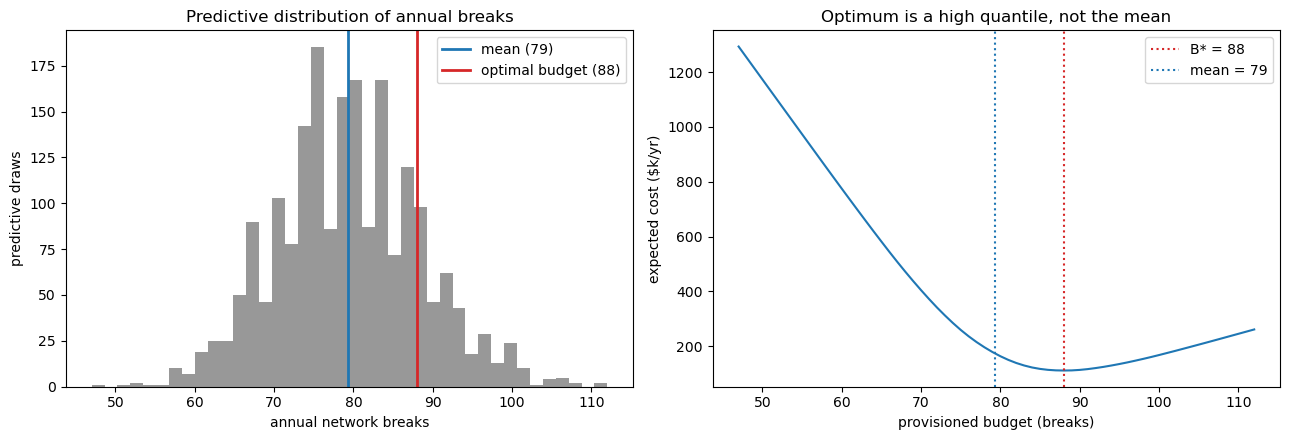

planning to the optimum instead of the mean saves $67,416/yr


In [9]:
Bgrid = np.arange(int(totals.min()), int(totals.max()) + 1)
exp_cost = np.array([(C_surge * np.maximum(totals - B, 0) + C_idle * np.maximum(B - totals, 0)).mean()
                     for B in Bgrid])
meanN = totals.mean()
saving = exp_cost[np.argmin(np.abs(Bgrid - round(meanN)))] - exp_cost.min()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(totals, bins=40, color="tab:gray", alpha=0.8)
ax[0].axvline(meanN, color="tab:blue", lw=2, label=f"mean ({meanN:.0f})")
ax[0].axvline(Bstar, color="tab:red", lw=2, label=f"optimal budget ({Bstar})")
ax[0].set_xlabel("annual network breaks"); ax[0].set_ylabel("predictive draws")
ax[0].set_title("Predictive distribution of annual breaks"); ax[0].legend()
ax[1].plot(Bgrid, exp_cost / 1e3)
ax[1].axvline(Bstar, color="tab:red", ls=":", label=f"B* = {Bstar}")
ax[1].axvline(meanN, color="tab:blue", ls=":", label=f"mean = {meanN:.0f}")
ax[1].set_xlabel("provisioned budget (breaks)"); ax[1].set_ylabel("expected cost ($k/yr)")
ax[1].set_title("Optimum is a high quantile, not the mean"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"planning to the optimum instead of the mean saves ${saving:,.0f}/yr")


## Takeaway

The GP gives a calibrated break rate with honest uncertainty. Passing the full
predictive through an asymmetric, dollar-denominated loss, instead of a point
estimate, changes which pipes to replace and how much emergency capacity to hold.
That is the payoff of decision theory over a plug-in prediction.